# 42 · CANDLE_SAVI · bulk_RNA_seq · heatmaps of the top genes

Reads `counts_combatseq.rds`, `samples.rds` (notebook 40) and `top_genes_<pair>.csv` (notebook 41). Writes
figures to `figures/CANDLE_SAVI/`.

**Values.** The ComBat-seq counts of notebook 40, corrected for batch, for display only; the differential
expression of notebook 41 used the raw counts. Counts are turned into log2 counts per million after TMM
normalization, and each gene is z-scored over the samples shown (mean 0, standard deviation 1); colours are
capped at -2.5 and 2.5, as in notebook 07.

**Heatmaps.**
- one for each of the six comparisons: that comparison's top genes (adjusted p < 0.05, fold change at least
  2), and the samples of its two diagnoses;
- one of all genes in any top list, over all 161 samples;
- one of the 28 interferon response genes and the 11 NF-kB-only control genes, over all 161 samples.

**Trees.** Ward's method, `ward.D2` (Ward JH. *J Am Stat Assoc* 1963;58:236-244; Murtagh F, Legendre P.
*J Classif* 2014;31:274-295), on Minkowski distance with p = 2, on samples and on genes. Strips on the left
show diagnosis and batch; samples are named by code only. Every heatmap names its genes. Where a
comparison has more than 80 top genes, the notebook shows the 50 with the smallest adjusted p, and the heatmap
of all its top genes, every gene named, is saved as a wide PNG.

## Read the values and the top genes

In [1]:
source("../src/paths.R")
suppressMessages({library(edgeR); library(ComplexHeatmap); library(circlize)})
x <- readRDS(art("CANDLE_SAVI", "counts_combatseq.rds")); s <- readRDS(art("CANDLE_SAVI", "samples.rds"))
stopifnot(identical(colnames(x$counts), s$sample))
dge <- calcNormFactors(DGEList(x$counts))
logcpm <- cpm(dge, log = TRUE)
pairs <- c("CANDLE-AGS", "SAVI-AGS", "UAID-AGS", "SAVI-CANDLE", "UAID-CANDLE", "UAID-SAVI")
top <- lapply(setNames(pairs, pairs), function(k) read.csv(art("CANDLE_SAVI", sprintf("top_genes_%s.csv", k))))
sapply(top, nrow)

CANDLE-AGS    SAVI-AGS    UAID-AGS SAVI-CANDLE UAID-CANDLE   UAID-SAVI 
       1049         545         348         139          32          10

**Explanation**
- `library(ComplexHeatmap)` draws heatmaps with trees and annotation strips (Gu Z, Eils R, Schlesner M.
  *Bioinformatics* 2016;32:2847-2849); `library(circlize)` provides `colorRamp2()`, which maps numbers to
  colours (Gu Z et al. *Bioinformatics* 2014;30:2811-2812).
- `calcNormFactors()` computes TMM normalization factors; `cpm(dge, log = TRUE)` gives log2 counts per million
  for every gene and sample.
- `top` reads the top genes of each comparison written by notebook 41; `sapply(top, nrow)` counts them.

## Heatmap function

In [2]:
dx_col <- c(AGS = "#1B9E77", `AGS-like` = "#66C2A5", CANDLE = "#D95F02", `CANDLE-like` = "#FC8D62",
            SAVI = "#7570B3", UAID = "#E7298A")
b_lev  <- sort(unique(s$batch)); b_col <- setNames(hcl.colors(length(b_lev), "Set 2"), b_lev)
heat <- function(genes, samples, title) {
  H  <- scale(t(logcpm[genes$gene_id, samples, drop = FALSE]))
  H  <- H[, colSums(is.na(H)) == 0, drop = FALSE]; Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  m  <- s[match(samples, s$sample), ]
  left <- rowAnnotation(diagnosis = m$diagnosis, batch = m$batch,
                        col = list(diagnosis = dx_col[unique(m$diagnosis)], batch = b_col[unique(m$batch)]),
                        annotation_name_gp = gpar(fontsize = 8))
  Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top", column_names_side = "top",
          show_row_names = TRUE, row_names_side = "left", row_names_gp = gpar(fontsize = 5),
          column_labels = genes$gene_name[match(colnames(H), genes$gene_id)],
          column_names_gp = gpar(fontsize = 6), left_annotation = left,
          column_title = sprintf("%s: %d genes x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2",
                                 title, ncol(H), nrow(H)), column_title_gp = gpar(fontsize = 9))
}
show_and_save <- function(ht, file, w, h, show = TRUE) {
  for (res in if (show) c(300, 100) else 300) {     # a 300 dpi PNG kept, a 100 dpi copy shown here
    f <- if (res == 300) fig("CANDLE_SAVI", file) else tempfile(fileext = ".png")
    png(f, width = w, height = h, units = "in", res = res); draw(ht); invisible(dev.off())
  }
  if (show) IRdisplay::display_png(file = f) else cat("saved, not shown:", file, sprintf("(%.0f x %.0f inches)", w, h), "\n")
}

**Explanation**
- `dx_col` and `b_col` give each diagnosis and each batch a colour; `hcl.colors()` picks a set of distinct
  colours.
- `heat(genes, samples, title)` draws one heatmap:
  - `scale(t(...))` makes samples the rows and z-scores each gene over the samples shown; genes that do not
    vary are dropped; `Hc` caps the colours at -2.5 and 2.5;
  - `hr` and `hc` are Ward trees of the samples and of the genes;
  - `left` shows diagnosis and batch next to the sample codes;
  - the sample tree and sample codes are on the left, the gene tree and gene names on top, each set of
    names next to its tree;
  - `column_labels` names every gene, replacing the Ensembl identifiers
    with gene names.
- `show_and_save(ht, file, w, h)` saves the heatmap as a 300 dpi PNG and shows a 100 dpi copy here; a notebook
  cell keeps only the last figure drawn in a loop, so each is shown from its file (see notebook 18).

## One heatmap per comparison

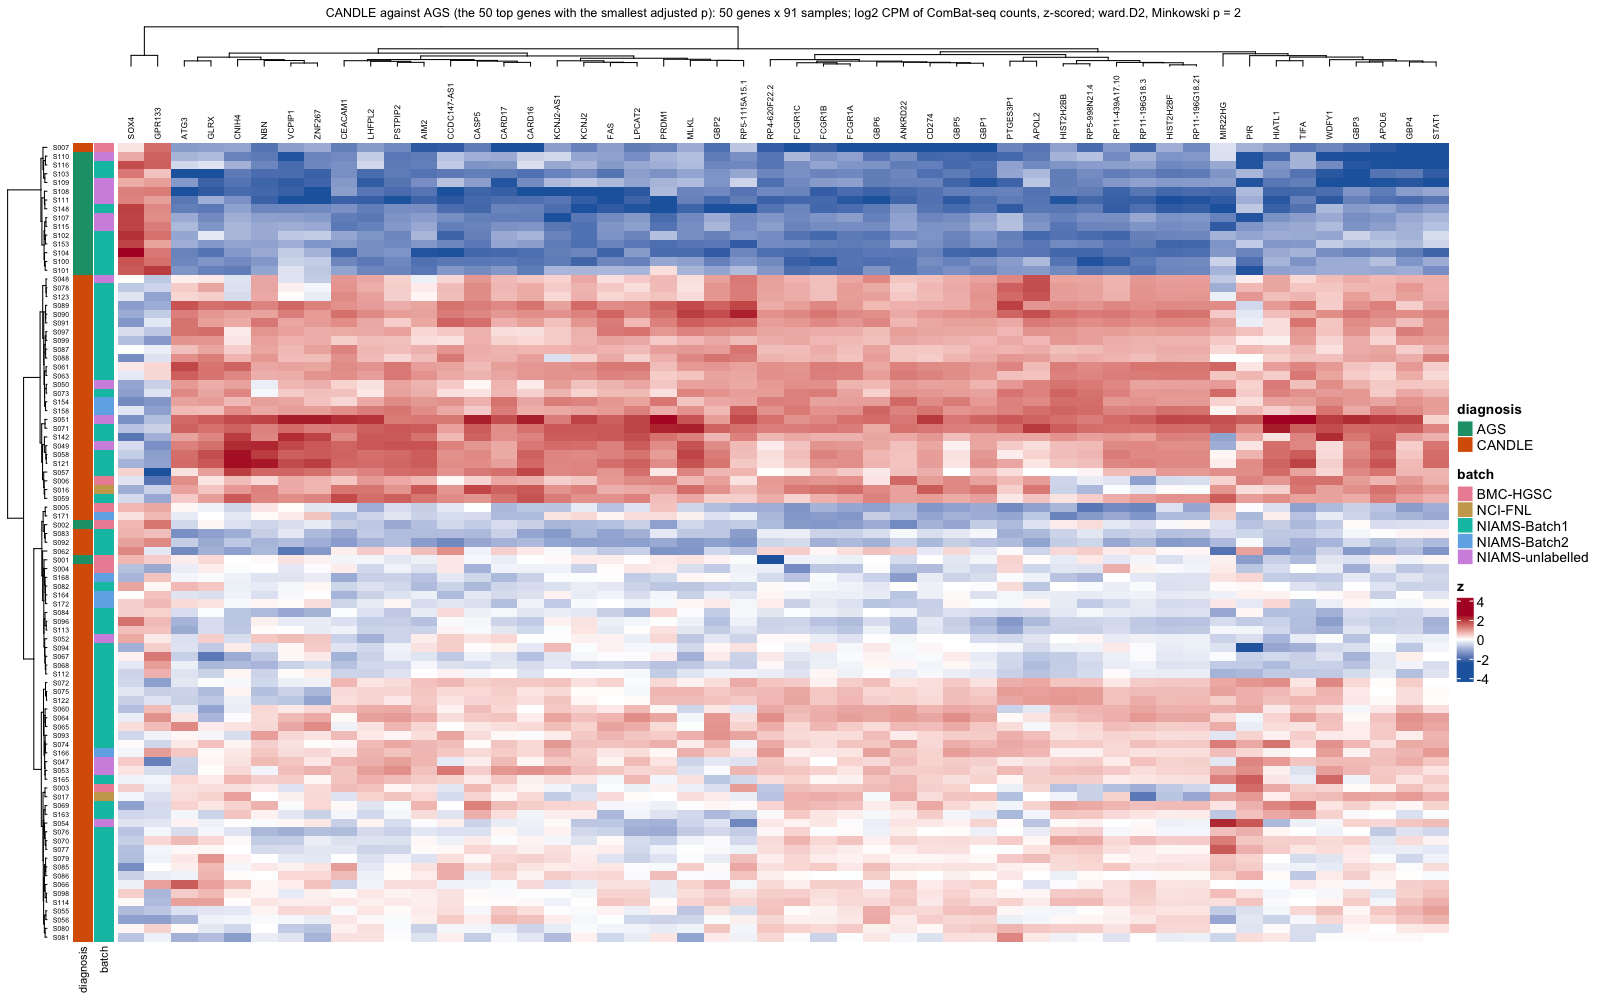

saved, not shown: 42_heatmap_CANDLE-AGS.png (77 x 10 inches) 


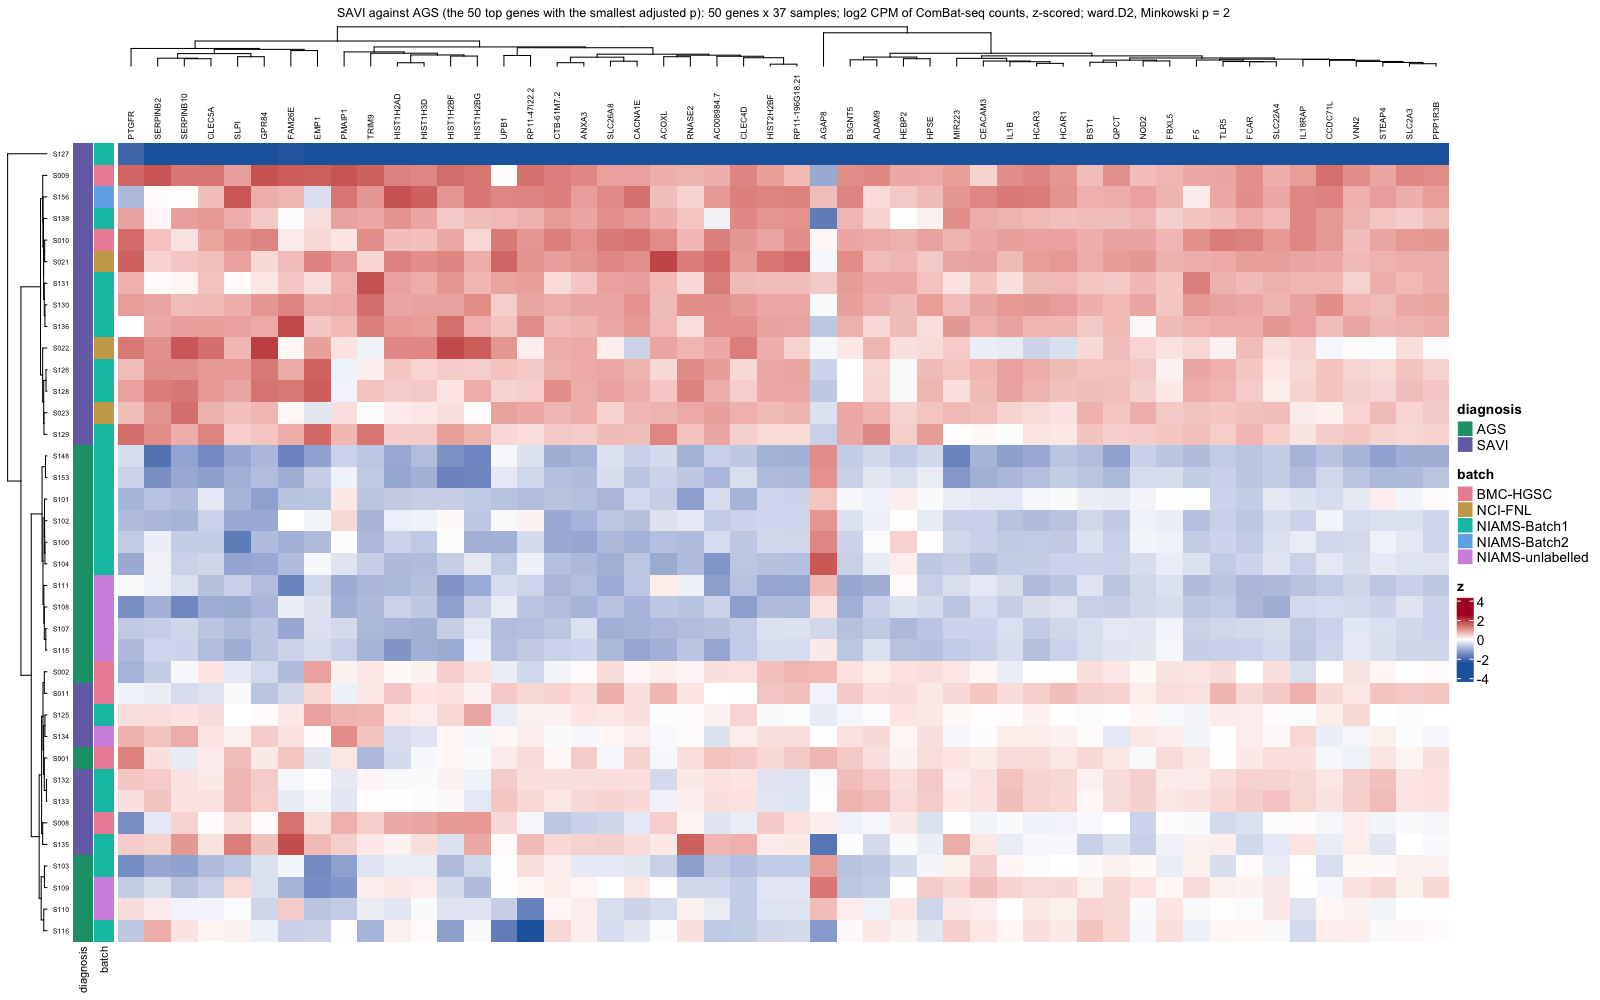

saved, not shown: 42_heatmap_SAVI-AGS.png (42 x 10 inches) 


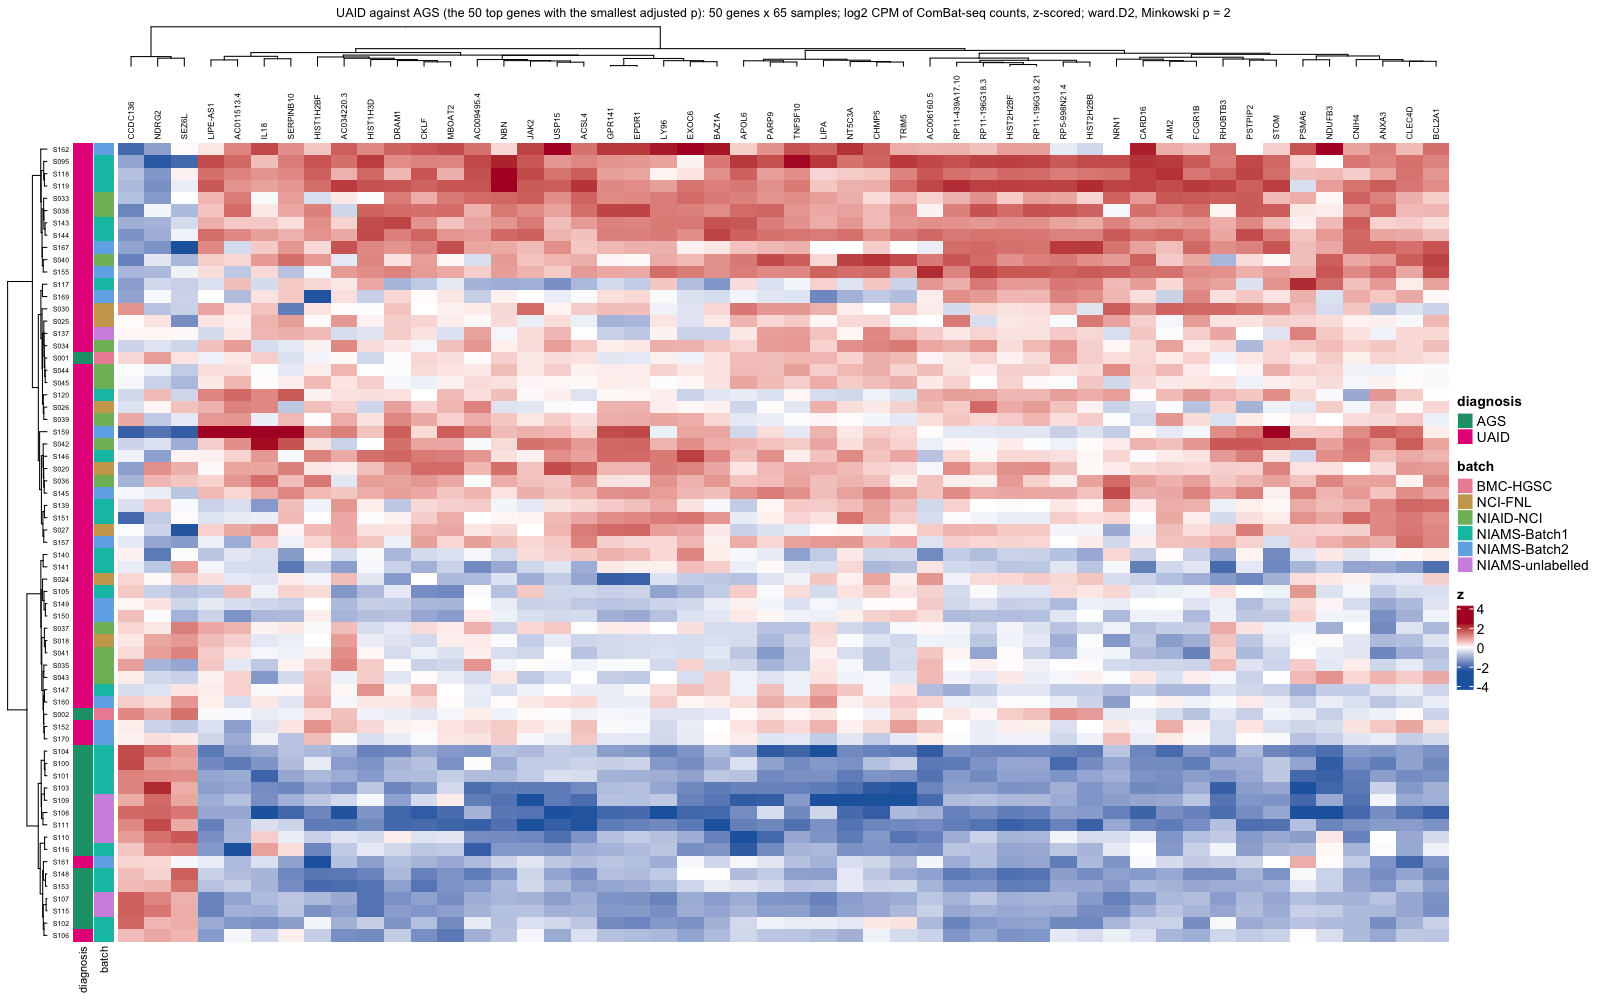

saved, not shown: 42_heatmap_UAID-AGS.png (28 x 10 inches) 


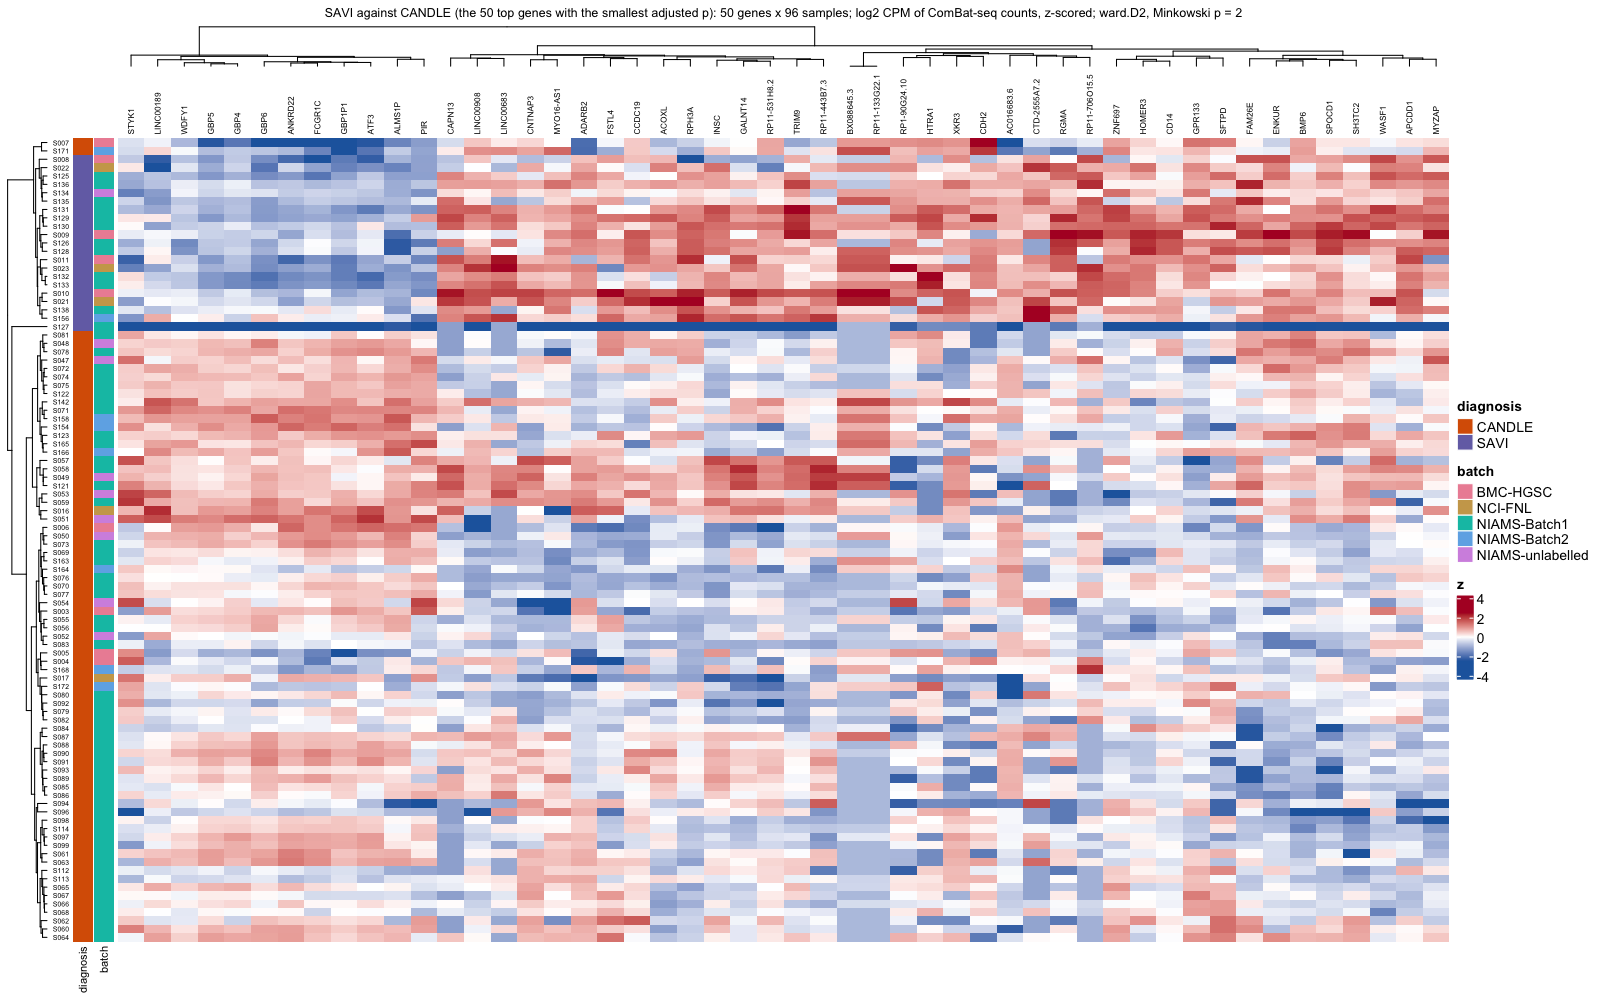

saved, not shown: 42_heatmap_SAVI-CANDLE.png (16 x 10 inches) 


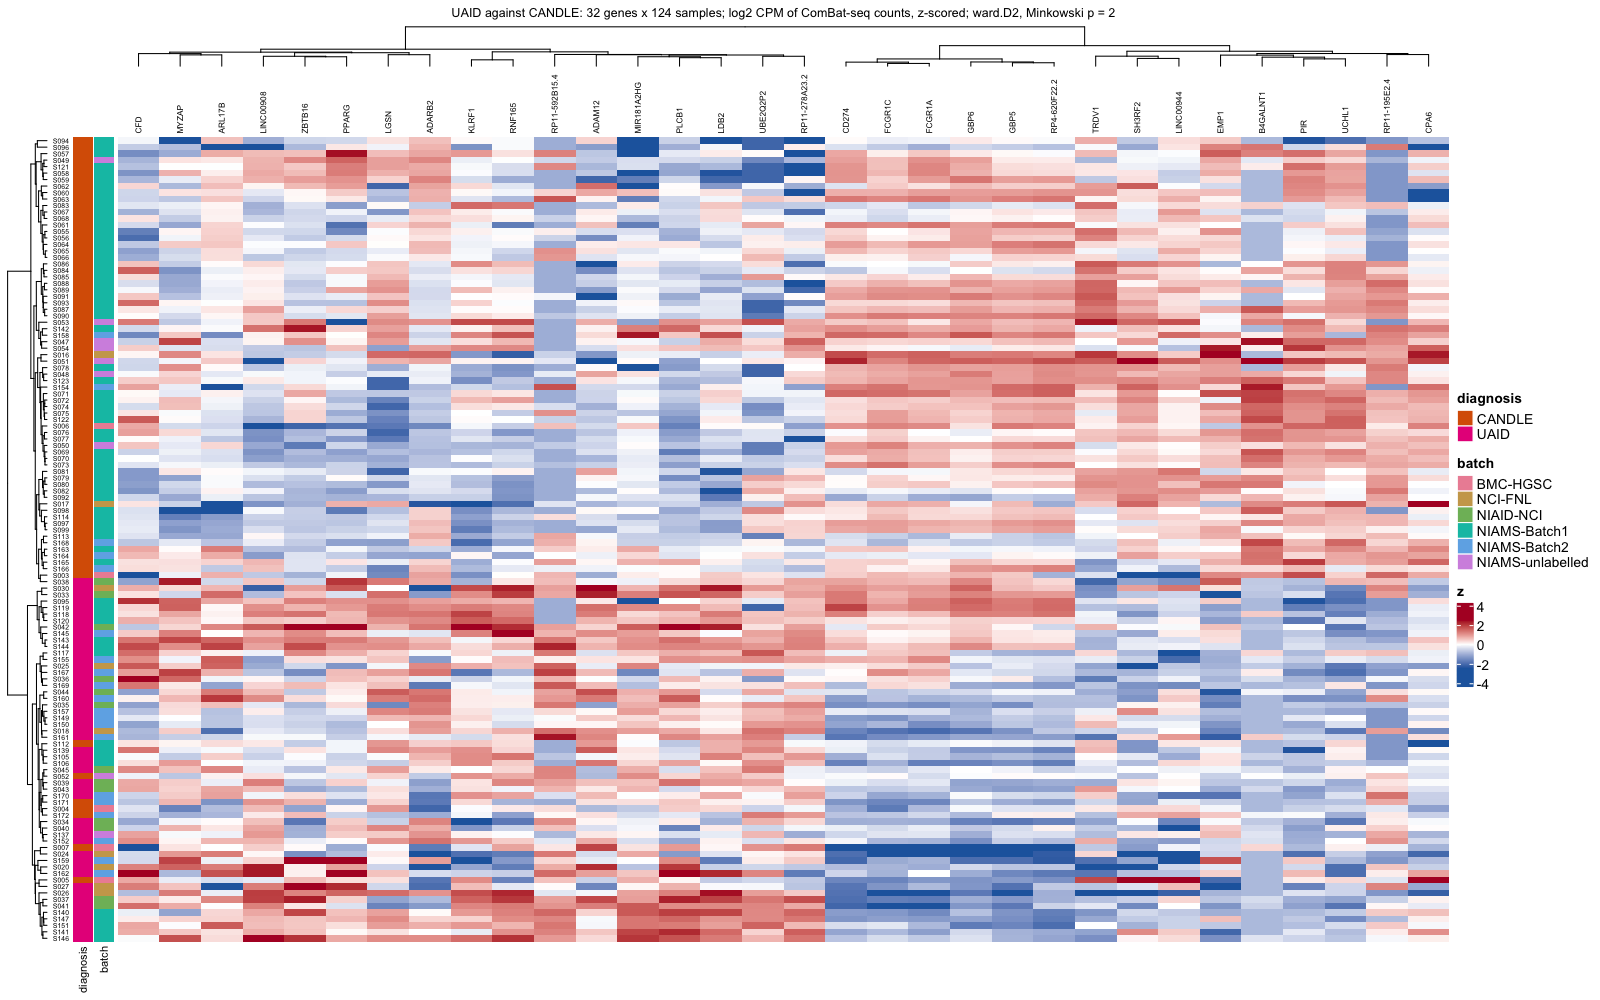

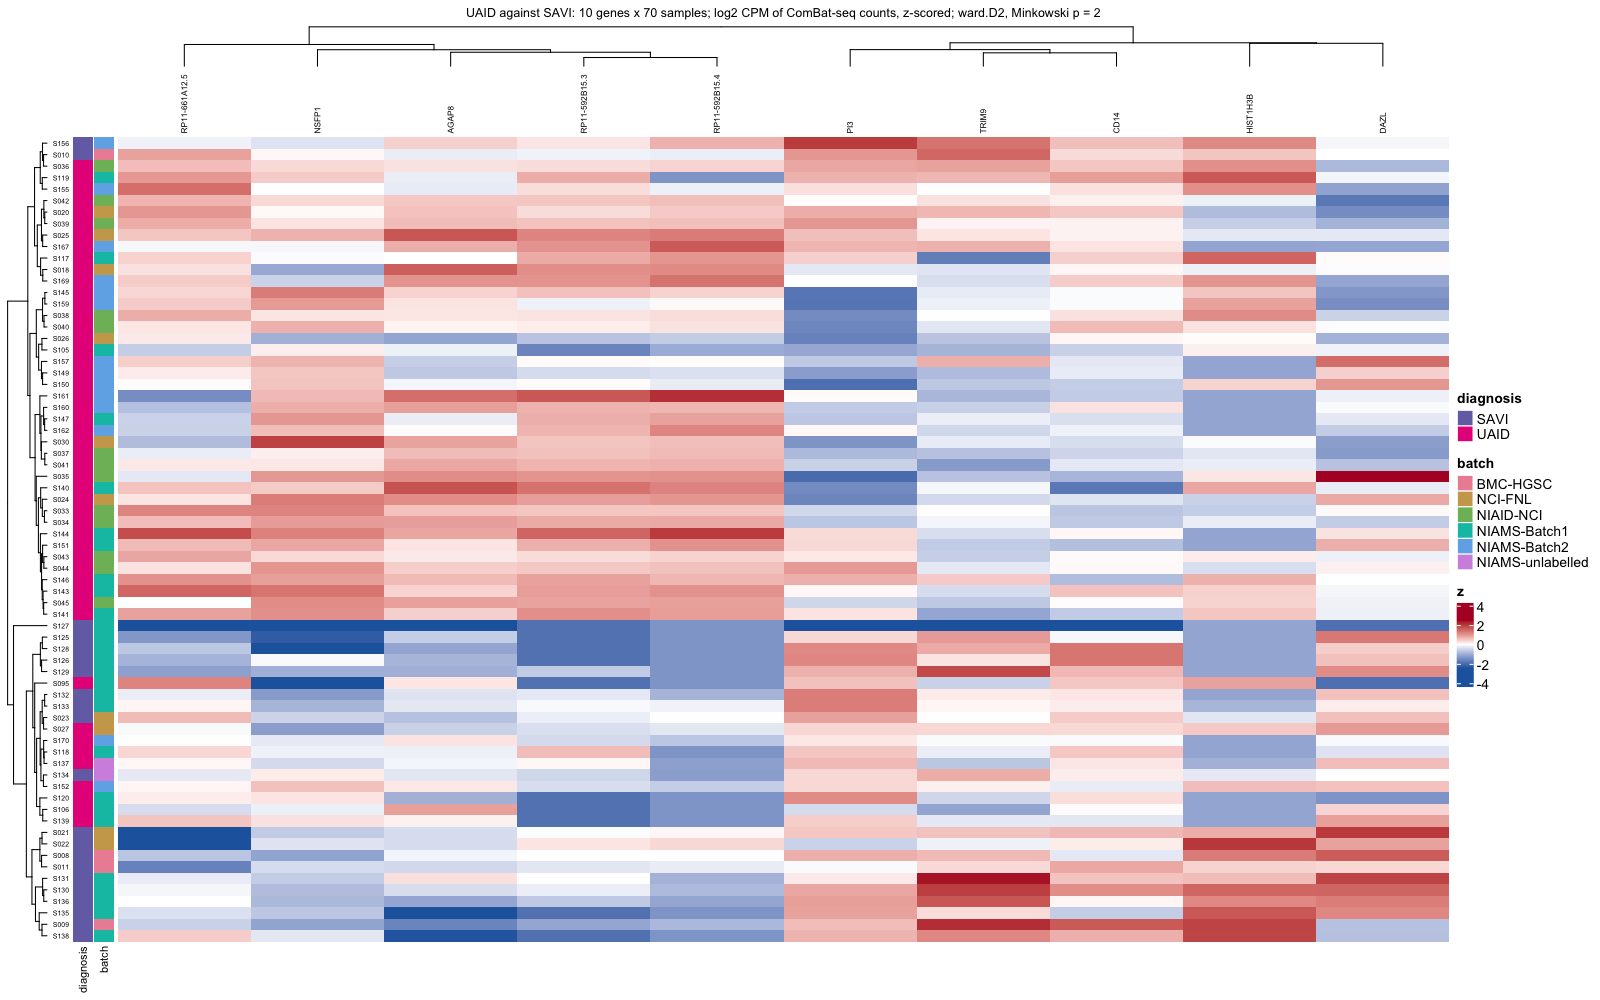

In [3]:
for (k in pairs) {
  g <- strsplit(k, "-")[[1]]
  samples <- s$sample[s$diagnosis %in% g]
  n <- nrow(top[[k]]); title <- sprintf("%s against %s", g[1], g[2])
  if (n > 80) {
    show_and_save(heat(head(top[[k]], 50), samples, paste(title, "(the 50 top genes with the smallest adjusted p)")),
                  sprintf("42_heatmap_%s_top50.png", k), 16, 10)
    show_and_save(heat(top[[k]], samples, paste(title, "(all top genes)")), sprintf("42_heatmap_%s.png", k),
                  max(16, 4 + 0.07 * n), 10, show = FALSE)
  } else show_and_save(heat(top[[k]], samples, title), sprintf("42_heatmap_%s.png", k), 16, 10)
}

**Explanation**
- For each comparison, `g` holds its two diagnoses and `samples` their samples; `n` counts its top genes.
- With more than 80 top genes, the notebook shows the heatmap of the 50 with the smallest adjusted p
  (`head(top[[k]], 50)`; the top lists are sorted by p), and saves the heatmap of all top genes, every gene
  named, 0.07 inches per gene wide (`show = FALSE` saves it without showing it). With 80 or fewer, one
  heatmap shows them all.

**Result.** CANDLE against AGS (1,049 top genes), SAVI against AGS (545), UAID against AGS (348) and SAVI
against CANDLE (139) are shown with their 50 top genes; the heatmaps of all their top genes are saved (16 to
77 inches wide). UAID against CANDLE (32) and UAID against SAVI (10) are shown whole. The first split of each
sample tree, in the heatmaps shown:

| comparison | genes x samples | first split of the sample tree |
|---|---|---|
| CANDLE against AGS | 50 x 91 | 14 of 16 AGS (with 1 CANDLE) against 74 of 75 CANDLE (with 2 AGS) |
| SAVI against AGS | 50 x 37 | one SAVI sample against the other 36 |
| UAID against AGS | 50 x 65 | 15 AGS and 17 UAID against 32 UAID and 1 AGS |
| SAVI against CANDLE | 50 x 96 | 20 of 21 SAVI (with 2 CANDLE) against 73 of 75 CANDLE (with 1 SAVI) |
| UAID against CANDLE | 32 x 124 | 68 CANDLE (with 1 UAID) against 48 UAID (with 7 CANDLE) |
| UAID against SAVI | 10 x 70 | 19 SAVI (with 9 UAID) against 40 UAID (with 2 SAVI) |

## All top genes, all samples

all_top_genes first_10_of_each_comparison 
                       1413                          52

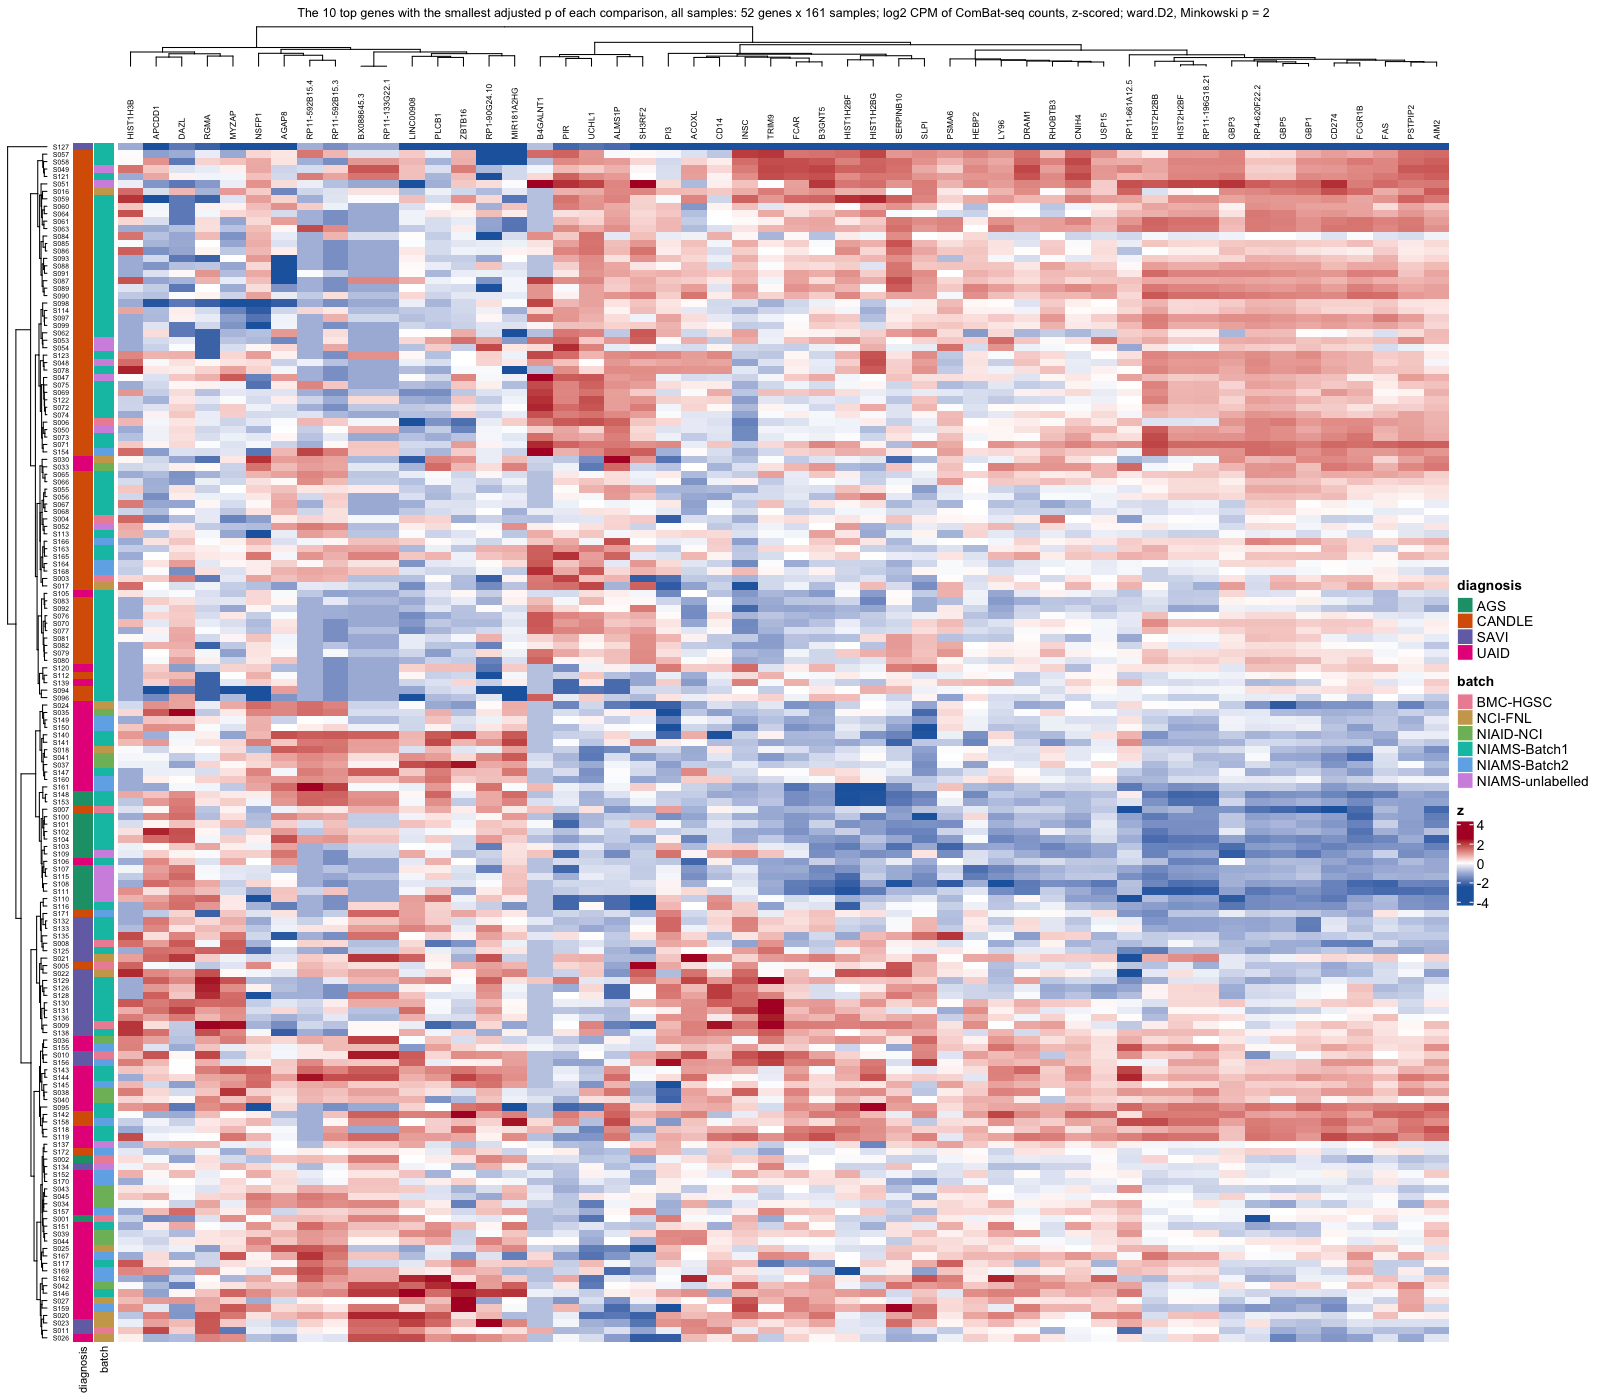

saved, not shown: 42_heatmap_all_top_genes.png (103 x 14 inches) 


In [4]:
all_top  <- unique(do.call(rbind, top)[, c("gene_id", "gene_name")])
first_10 <- unique(do.call(rbind, lapply(top, head, 10))[, c("gene_id", "gene_name")])
c(all_top_genes = nrow(all_top), first_10_of_each_comparison = nrow(first_10))
show_and_save(heat(first_10, s$sample, "The 10 top genes with the smallest adjusted p of each comparison, all samples"),
              "42_heatmap_top10_each_comparison.png", 16, 14)
show_and_save(heat(all_top, s$sample, "All top genes, all samples"), "42_heatmap_all_top_genes.png",
              max(16, 4 + 0.07 * nrow(all_top)), 14, show = FALSE)

**Explanation**
- `do.call(rbind, top)` stacks the six top lists; `unique()` keeps each gene once.
- `first_10` holds the 10 top genes with the smallest adjusted p of each comparison, each gene once; this
  heatmap is shown. The heatmap of all top genes, every gene named, is saved.
- Both show all 161 samples.

**Result.** 1,413 genes are in at least one top list; 52 are among the 10 top genes of a comparison. In the
heatmap of these 52 genes over the 161 samples, the first split of the sample tree sets S127 (NIAMS-Batch1,
SAVI) apart from the other 160; S127 is also apart in the PCA of notebook 40. The heatmap of all 1,413 genes
is saved (103 inches wide).

## The 28 interferon response genes and the 11 NF-kB-only controls

In [5]:
GENES <- x$genes
irg <- read_gene_set("ifn-response-genes-28.txt"); nfk <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
dj3 <- read_gene_set("ifn-response-genes-3-stat1-nfkb-dejesus2020.txt")
ifn <- data.frame(gene_name = c(irg, nfk), set = rep(c("IRG-28", "NF-kB-11"), c(length(irg), length(nfk))))
ifn$subscore <- ifelse(ifn$set == "NF-kB-11", "control", ifelse(ifn$gene_name %in% dj3, "3 STAT1/NF-kB", "25 STAT1-only"))
ifn$gene_id  <- GENES$gene_id[match(ifn$gene_name, GENES$gene_name)]
ifn_heat <- function(logcpm, left, title) {
  g  <- ifn[!is.na(ifn$gene_id), ]
  H  <- scale(t(logcpm[g$gene_id, , drop = FALSE])); keep <- colSums(is.na(H)) == 0
  H  <- H[, keep, drop = FALSE]; g <- g[keep, ]; Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  top_ann <- HeatmapAnnotation(set = g$set, subscore = g$subscore,
                               col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40"),
                                          subscore = c("25 STAT1-only" = "steelblue", "3 STAT1/NF-kB" = "firebrick", control = "grey80")),
                               annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
  ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
                cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top",
                row_names_side = "left", row_names_gp = gpar(fontsize = 5), column_labels = g$gene_name,
                column_names_side = "top", column_names_gp = gpar(fontsize = 8),
                top_annotation = top_ann, left_annotation = left, column_title_gp = gpar(fontsize = 9),
                column_title = sprintf("%s: 28 interferon response genes and 11 NF-kB-only controls x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", title, nrow(H)))
  list(ht = ht, rows = hr, cols = hc, genes = g)
}
c(interferon_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "IRG-28"])), control_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "NF-kB-11"])))

interferon_genes_found    control_genes_found 
                    28                     11

**Explanation**
- The gene lists are those of notebooks 05c, 15c and 26c (`genes/`, see notebook 00 for `read_gene_set()`):
  - `ifn-response-genes-28.txt`: the 28 interferon response genes listed in Kim H et al. *J Interferon
    Cytokine Res* 2018;38:171-185 (Supplementary Table S1) and in de Jesus AA et al. *J Clin Invest*
    2020;130:1669-1682 (Supplemental Figure 3B);
  - `ifn-response-genes-3-stat1-nfkb-dejesus2020.txt`: CXCL10, GBP1 and SOCS1, which de Jesus 2020 separates
    as genes with STAT1 and NF-kB binding sites; the other 25 are STAT1-only;
  - `nfkb-only-control-11-dejesus2020.txt`: 11 NF-kB target genes with no STAT1, STAT2 or TYK1 binding site,
    the control (de Jesus 2020).
- `ifn` lists the 39 genes with their set and subscore; `gene_id` finds each gene's Ensembl identifier by its
  name in these data.
- `ifn_heat(logcpm, left, title)` draws the heatmap: samples as rows, genes as columns, each gene z-scored,
  colours capped at -2.5 and 2.5; Ward trees on both axes; strips on top for set and subscore, and `left` for
  the samples. It returns the heatmap and the two trees.
- The last line counts the genes found.

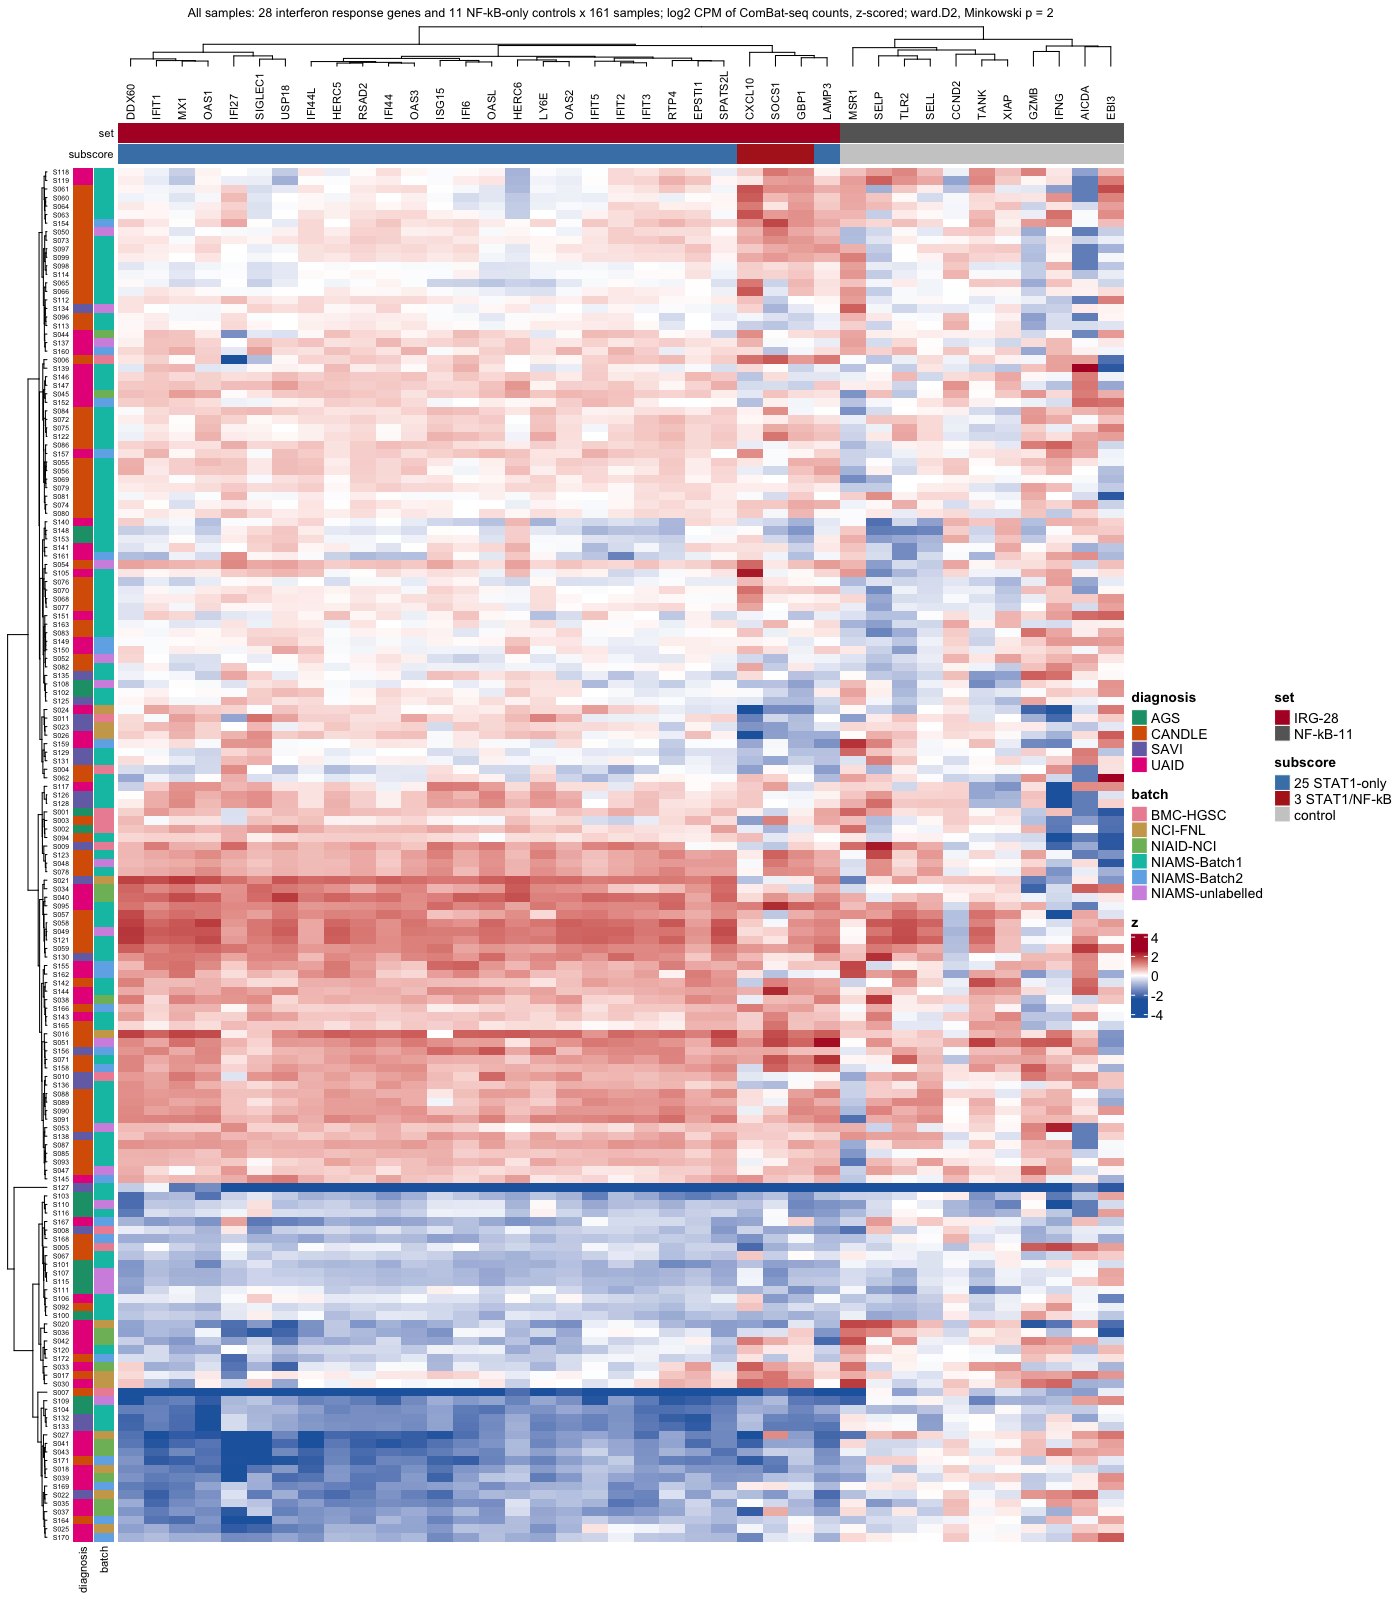

      diagnosis
branch AGS CANDLE SAVI UAID
     1   6     66   16   31
     2  10      9    5   18

$`1`
 [1] "CXCL10"  "DDX60"   "EPSTI1"  "GBP1"    "HERC5"   "HERC6"   "IFI27"  
 [8] "IFI44"   "IFI44L"  "IFI6"    "IFIT1"   "IFIT2"   "IFIT3"   "IFIT5"  
[15] "ISG15"   "LAMP3"   "LY6E"    "MX1"     "OAS1"    "OAS2"    "OAS3"   
[22] "OASL"    "RSAD2"   "RTP4"    "SIGLEC1" "SOCS1"   "SPATS2L" "USP18"  

$`2`
 [1] "AICDA" "CCND2" "EBI3"  "GZMB"  "IFNG"  "MSR1"  "SELP"  "TANK"  "TLR2" 
[10] "SELL"  "XIAP"

In [6]:
r <- ifn_heat(logcpm, rowAnnotation(diagnosis = s$diagnosis, batch = s$batch, col = list(diagnosis = dx_col[unique(s$diagnosis)], batch = b_col[unique(s$batch)]), annotation_name_gp = gpar(fontsize = 8)), "All samples")
for (res in c(300, 100)) {                          # a 300 dpi PNG kept, a 100 dpi copy shown here
  f <- if (res == 300) fig("CANDLE_SAVI", "42_interferon_heatmap.png") else tempfile(fileext = ".png")
  png(f, width = 14, height = 16, units = "in", res = res); draw(r$ht); invisible(dev.off())
}
IRdisplay::display_png(file = f)
table(branch = cutree(r$rows, 2), diagnosis = s$diagnosis)
split(r$genes$gene_name, cutree(r$cols, 2))

**Explanation**
- `ifn_heat()` draws the heatmap; it is saved at 300 dpi and shown at 100 dpi.
- `cutree(r$rows, 2)` gives the first split of the sample tree, crossed with the samples' labels;
  `cutree(r$cols, 2)` gives the first split of the gene tree, listed by branch.

**Result.** All 28 interferon response genes are found. The first split of the gene tree separates the 28
interferon response genes from the 11 NF-kB-only controls. The first split of the sample tree separates 119
samples with higher interferon values (mean z of the 28 genes 0.39) from 42 with lower values (-1.11): the
lower branch holds 10 of 16 AGS, 9 of 75 CANDLE, 5 of 21 SAVI and 18 of 49 UAID samples. The median z of the
28 genes is -0.56 in AGS, 0.28 in CANDLE, 0.09 in SAVI and 0.07 in UAID.